# VC-Genome: OAR Profile by VisType (Human / B Condition)

**Goal:** Characterise how the human-phrase OAR extractions (condition B, 510 images) differ *across* the 9 main VisTypes.  
We ask:
1. **Volume** — how many objects / attributes / relationships per image in each VisType?
2. **Category profile** — what object *roles* (mark, text, furniture, …) dominate each VisType?
3. **Cross-VisType vocabulary similarity** — do different VisTypes share the same object vocabulary (Jaccard) or diverge (cosine distance)?
4. **VisType-specific vs universal terms** — which synsets appear in only one VisType, and which span all nine?
5. **Predicate profile** — which relationship predicates characterise each VisType?

**Data:** `vc_genome_output_full/three_conditions/oar_B_510.json` + `phrase_reduction_v2/image_compiled_phrases.csv`

In [ ]:
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path

sys.path.insert(0, 'scripts')
from _vc_canon import resolve_predicate
from _vc_canon_extended_B import resolve_object_synset_extended as resolve_object_synset

ROOT      = Path('.')
THREE_DIR = ROOT / 'vc_genome_output_full' / 'three_conditions'
OUT       = ROOT / 'vc_genome_output_full' / 'vistype_profile'
OUT.mkdir(parents=True, exist_ok=True)

NINE_VIS = ['Area', 'Bar', 'Cont.-ColorPatn', 'Glyph', 'Grid',
            'Line', 'Node-link', 'Point', 'Text']

# ── Load data ─────────────────────────────────────────────────────────────
with open(THREE_DIR / 'oar_B_510.json', encoding='utf-8') as f:
    b_raw = json.load(f)

phrases = (pd.read_csv('phrase_reduction_v2/image_compiled_phrases.csv',
                       usecols=['imageName', 'VisType'])
             .drop_duplicates('imageName'))
vistype_map = phrases.set_index('imageName')['VisType'].to_dict()

vt_images = {
    vt: [img for img, v in vistype_map.items() if v == vt and img in b_raw]
    for vt in NINE_VIS
}
print('Images per VisType:')
for vt, imgs in vt_images.items():
    print(f'  {vt:20s}  {len(imgs):3d}')


Images per VisType:
  Area                   65
  Bar                    51
  Cont.-ColorPatn        42
  Glyph                  64
  Grid                   65
  Line                   48
  Node-link              66
  Point                  58
  Text                   51


## 1. Volume: OAR Counts per Image

In [16]:
# ── Build per-image volume rows ────────────────────────────────────────────
from _vc_canon import normalize_attr

rows = []
for vt, imgs in vt_images.items():
    for img in imgs:
        ext = b_raw[img]

        # Raw token counts
        n_obj  = len(ext['objects'])
        n_attr = len(ext['attributes'])
        n_rel  = len(ext['relationships'])

        # Unique counts (deduplicated by canonical key)
        obj_id_to_syn = {o['id']: resolve_object_synset(o['name']) for o in ext['objects']}
        n_obj_uniq  = len({resolve_object_synset(o['name']) for o in ext['objects']})
        n_attr_uniq = len({(obj_id_to_syn.get(a.get('object_id')),
                            normalize_attr(a.get('attr', a.get('name', ''))))
                           for a in ext['attributes']})
        n_rel_uniq  = len({(obj_id_to_syn.get(r.get('subj')),
                            resolve_predicate(r.get('pred', '')),
                            obj_id_to_syn.get(r.get('obj')))
                           for r in ext['relationships']})

        rows.append({
            'imageName':   img,
            'VisType':     vt,
            'n_obj':       n_obj,
            'n_attr':      n_attr,
            'n_rel':       n_rel,
            'n_obj_uniq':  n_obj_uniq,
            'n_attr_uniq': n_attr_uniq,
            'n_rel_uniq':  n_rel_uniq,
        })

vol = pd.DataFrame(rows)

# Summary table — raw and unique side by side
all_cols = ['n_obj', 'n_attr', 'n_rel', 'n_obj_uniq', 'n_attr_uniq', 'n_rel_uniq']
summary = (vol.groupby('VisType')[all_cols]
              .agg(['mean', 'median', 'std'])
              .round(2)
              .loc[NINE_VIS])
display(summary)
summary.to_csv(OUT / 'volume_summary.csv')


n_obj              n_attr              n_rel               \
                 mean median   std   mean median   std  mean median   std   
VisType                                                                     
Area             2.89    3.0  1.56   4.31    3.0  4.91  1.85    2.0  1.47   
Bar              2.39    2.0  1.31   2.84    2.0  2.30  1.29    1.0  1.14   
Cont.-ColorPatn  2.90    3.0  1.36   3.93    3.0  3.81  1.93    2.0  1.37   
Glyph            2.55    2.5  1.31   3.20    3.0  2.30  1.56    2.0  1.30   
Grid             2.80    3.0  1.42   3.63    3.0  3.62  1.72    2.0  1.24   
Line             2.98    3.0  1.44   3.48    3.0  2.08  1.81    2.0  1.21   
Node-link        3.06    3.0  1.53   4.11    3.0  2.88  2.05    2.0  1.47   
Point            3.31    3.0  1.70   4.29    3.5  3.37  2.19    2.0  1.46   
Text             2.71    2.0  1.50   3.24    3.0  2.36  1.73    2.0  1.22   

                n_obj_uniq              n_attr_uniq              n_rel_uniq  \
                      mean median   std        mean median   std       mean   
VisType                                                                       
Area                  2.82    3.0  1.43        4.31    3.0  4.91       1.85   
Bar                   2.27    2.0  1.25        2.84    2.0  2.30       1.29   
Cont.-ColorPatn       2.76    3.0  1.36        3.93    3.0  3.81       1.93   
Glyph                 2.48    2.0  1.28        3.20    3.0  2.30       1.53   
Grid                  2.68    2.0  1.29        3.63    3.0  3.62       1.72   
Line                  2.83    3.0  1.42        3.44    3.0  2.08       1.81   
Node-link             2.92    3.0  1.43        4.11    3.0  2.88       2.05   
Point                 3.10    3.0  1.54        4.28    3.0  3.37       2.17   
Text                  2.55    2.0  1.38        3.24    3.0  2.36       1.73   

                              
                median   std  
VisType                       
Area               2.0  1.47  
Bar                1.0  1.14  
Cont.-ColorPatn    2.0  1.37  
Glyph              2.0  1.23  
Grid               2.0  1.24  
Line               2.0  1.21  
Node-link          2.0  1.47  
Point              2.0  1.44  
Text               2.0  1.22

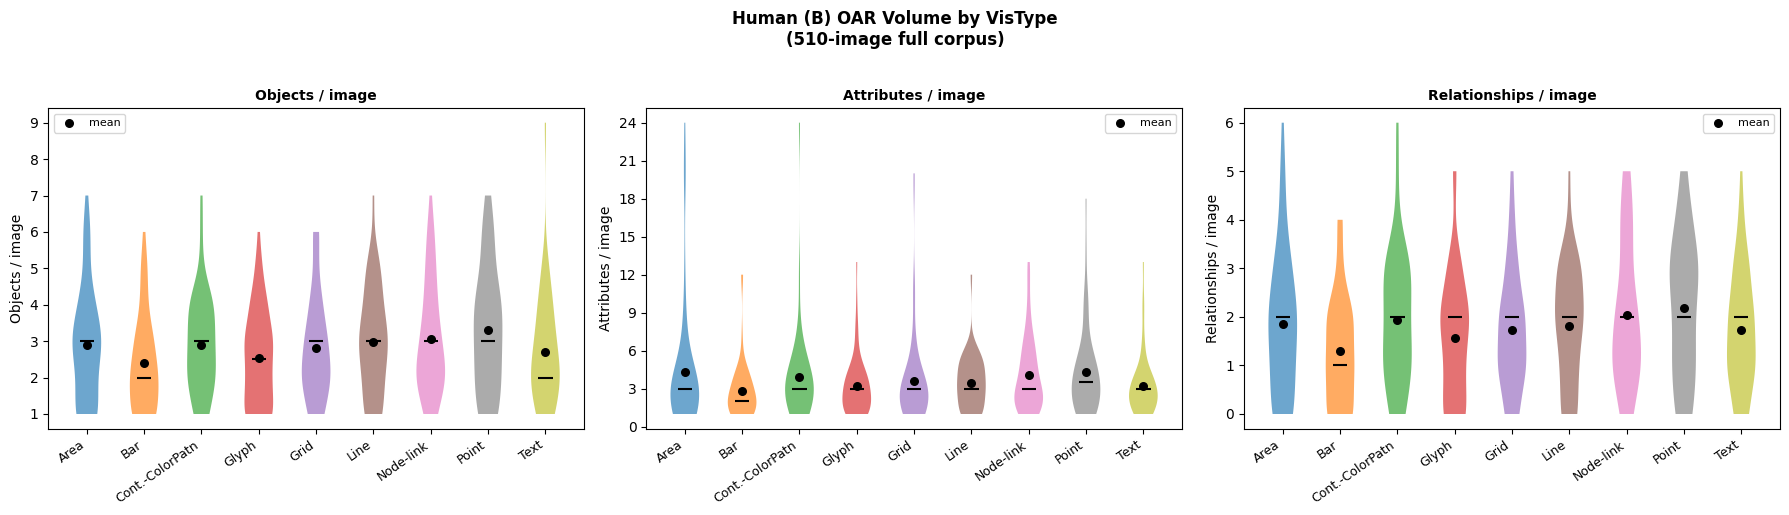

Saved → volume_violins.png


In [17]:
# ── Violin plots: one row per metric, one violin per VisType ──────────────
VT_COLORS = dict(zip(NINE_VIS, plt.cm.tab10.colors))

metrics = [('n_obj', 'Objects / image'), ('n_attr', 'Attributes / image'), ('n_rel', 'Relationships / image')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, label) in zip(axes, metrics):
    data   = [vol.loc[vol['VisType'] == vt, col].values for vt in NINE_VIS]
    means  = [d.mean() for d in data]
    parts  = ax.violinplot(data, positions=range(len(NINE_VIS)),
                           showmedians=True, showextrema=False)
    for i, (body, vt) in enumerate(zip(parts['bodies'], NINE_VIS)):
        body.set_facecolor(VT_COLORS[vt])
        body.set_alpha(0.65)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)
    ax.scatter(range(len(NINE_VIS)), means, color='black', s=30, zorder=5, label='mean')
    ax.set_xticks(range(len(NINE_VIS)))
    ax.set_xticklabels(NINE_VIS, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)

plt.suptitle('Human (B) OAR Volume by VisType\n(510-image full corpus)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUT / 'volume_violins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → volume_violins.png')

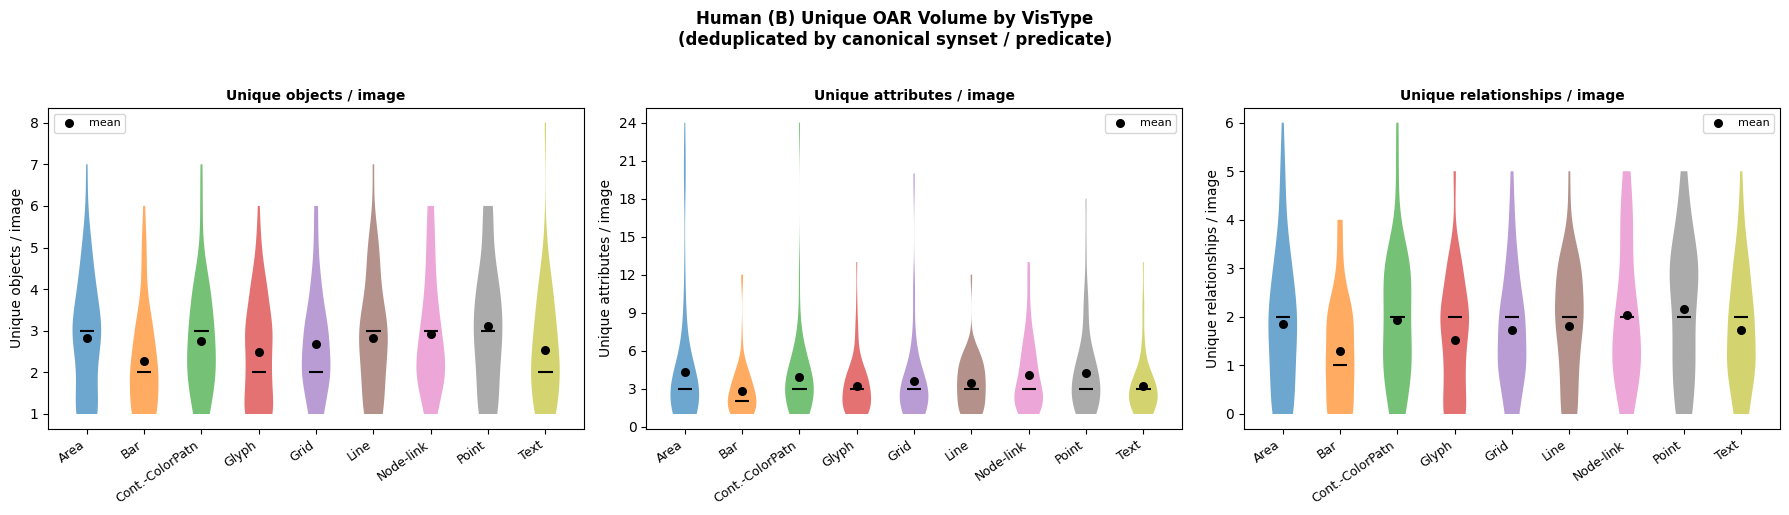

Saved → volume_violins_unique.png


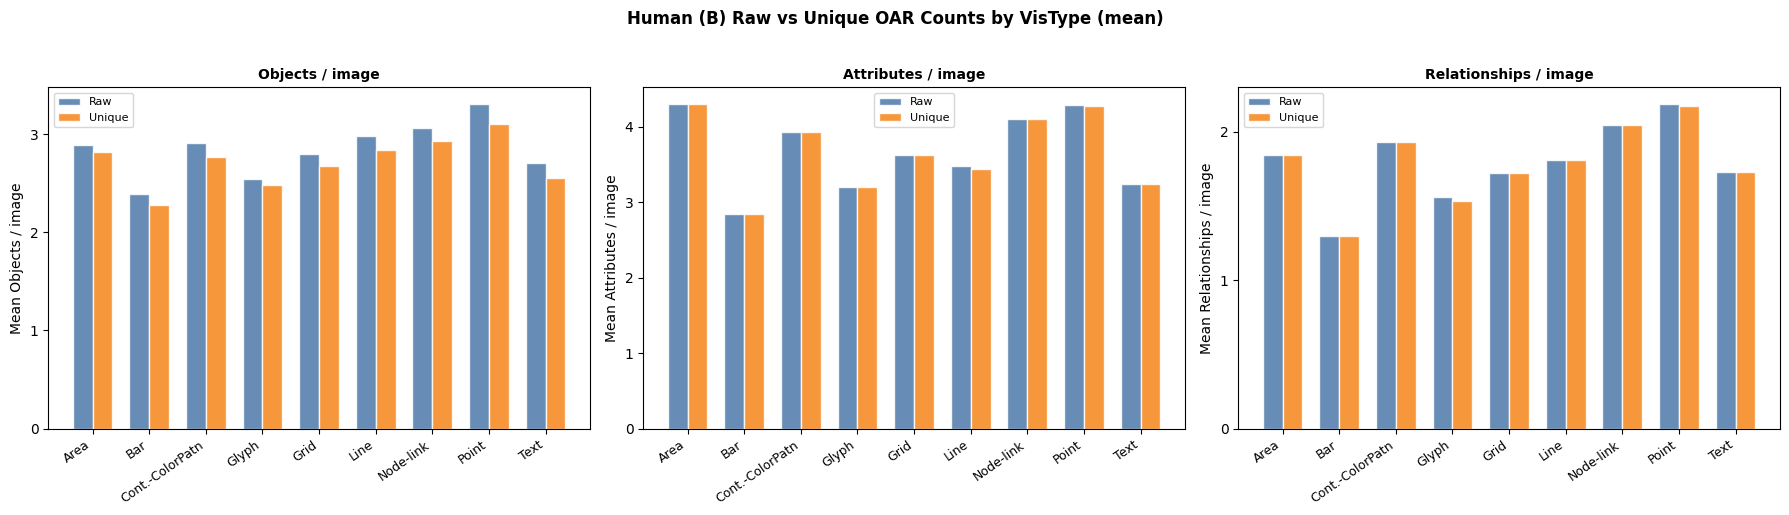

Saved → volume_raw_vs_unique.png


In [28]:
# ── Violin plots: unique (deduplicated) OAR counts per VisType ────────────
metrics_uniq = [
    ('n_obj_uniq',  'Unique objects / image'),
    ('n_attr_uniq', 'Unique attributes / image'),
    ('n_rel_uniq',  'Unique relationships / image'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, label) in zip(axes, metrics_uniq):
    data  = [vol.loc[vol['VisType'] == vt, col].values for vt in NINE_VIS]
    means = [d.mean() for d in data]
    parts = ax.violinplot(data, positions=range(len(NINE_VIS)),
                          showmedians=True, showextrema=False)
    for body, vt in zip(parts['bodies'], NINE_VIS):
        body.set_facecolor(VT_COLORS[vt])
        body.set_alpha(0.65)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)
    ax.scatter(range(len(NINE_VIS)), means, color='black', s=30, zorder=5, label='mean')
    ax.set_xticks(range(len(NINE_VIS)))
    ax.set_xticklabels(NINE_VIS, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)

plt.suptitle('Human (B) Unique OAR Volume by VisType\n(deduplicated by canonical synset / predicate)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUT / 'volume_violins_unique.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → volume_violins_unique.png')

# ── Side-by-side comparison: raw vs unique mean per VisType ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
raw_uniq_pairs = [
    ('n_obj',  'n_obj_uniq',  'Objects / image'),
    ('n_attr', 'n_attr_uniq', 'Attributes / image'),
    ('n_rel',  'n_rel_uniq',  'Relationships / image'),
]
x = np.arange(len(NINE_VIS))
w = 0.35

for ax, (raw_col, uniq_col, label) in zip(axes, raw_uniq_pairs):
    raw_means  = [vol.loc[vol['VisType'] == vt, raw_col].mean()  for vt in NINE_VIS]
    uniq_means = [vol.loc[vol['VisType'] == vt, uniq_col].mean() for vt in NINE_VIS]
    ax.bar(x - w/2, raw_means,  width=w, label='Raw',    color='#4C78A8', alpha=0.85, edgecolor='white')
    ax.bar(x + w/2, uniq_means, width=w, label='Unique', color='#F58518', alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(NINE_VIS, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(f'Mean {label}', fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)

plt.suptitle('Human (B) Raw vs Unique OAR Counts by VisType (mean)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUT / 'volume_raw_vs_unique.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → volume_raw_vs_unique.png')


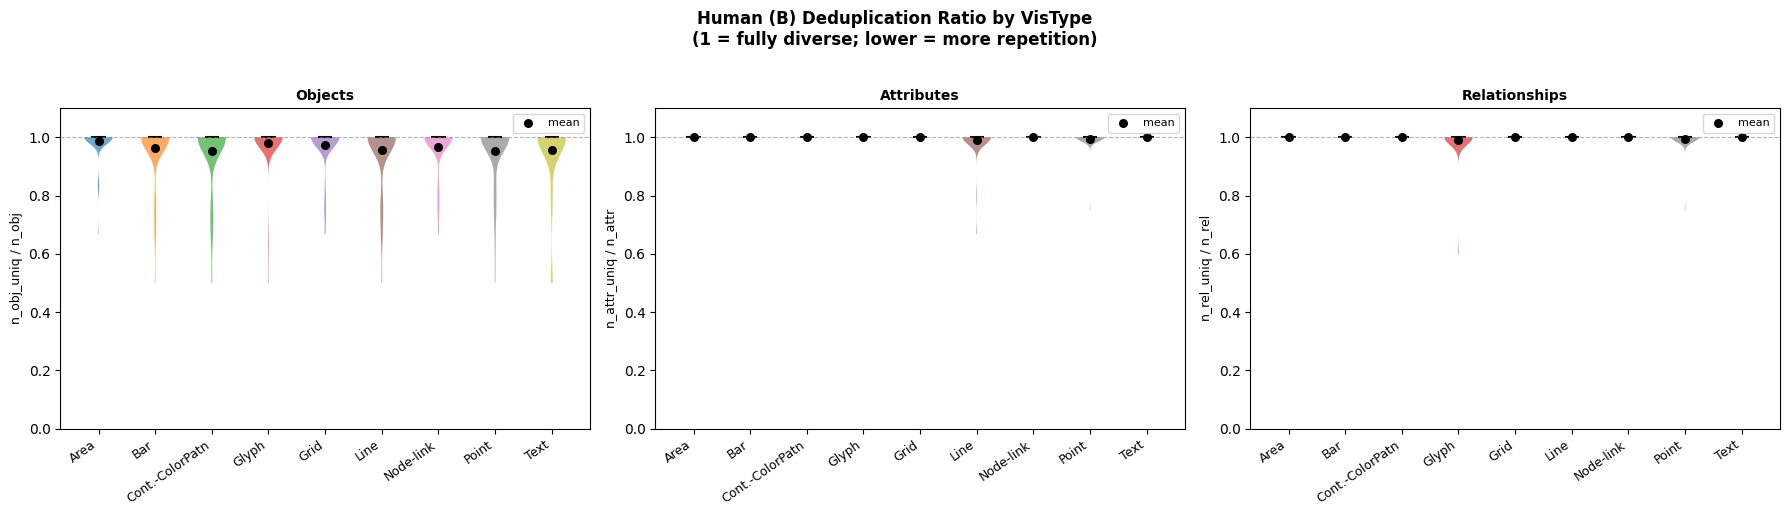

Saved → dedup_ratio_violins.png


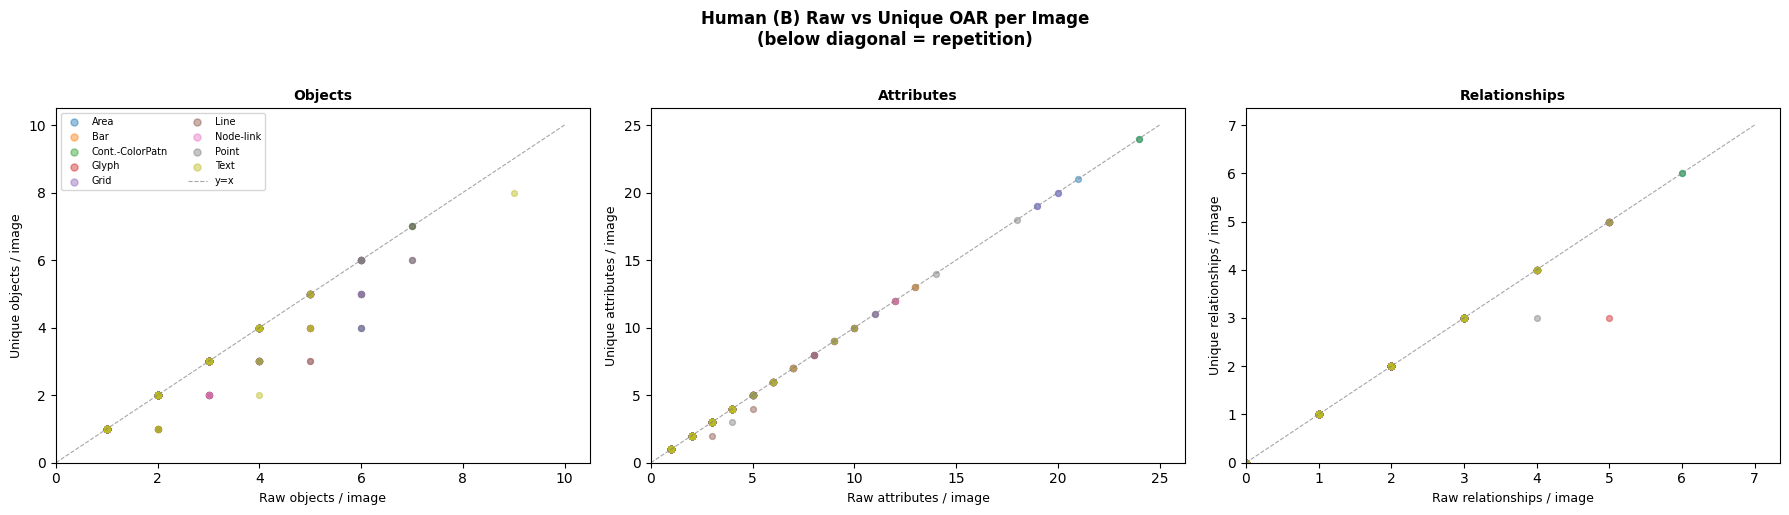

Saved → raw_vs_unique_scatter.png


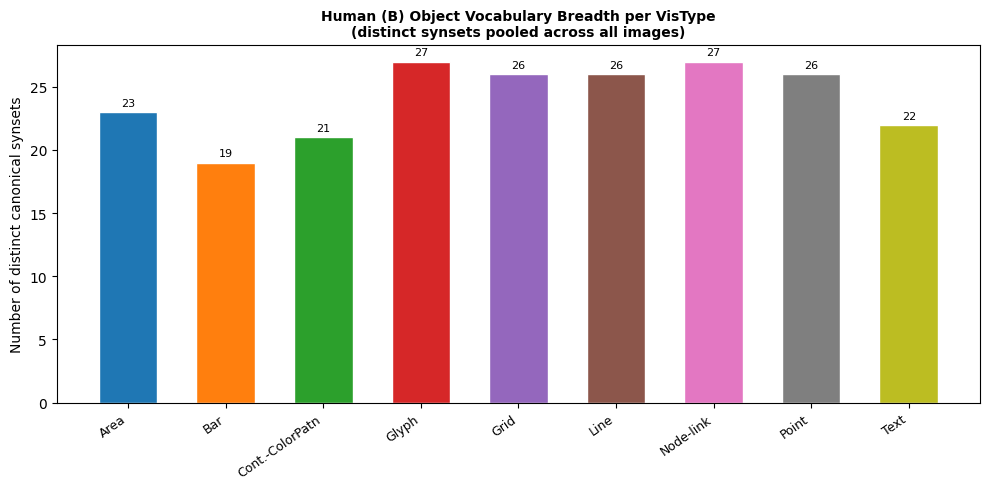

Saved → vocab_breadth.png


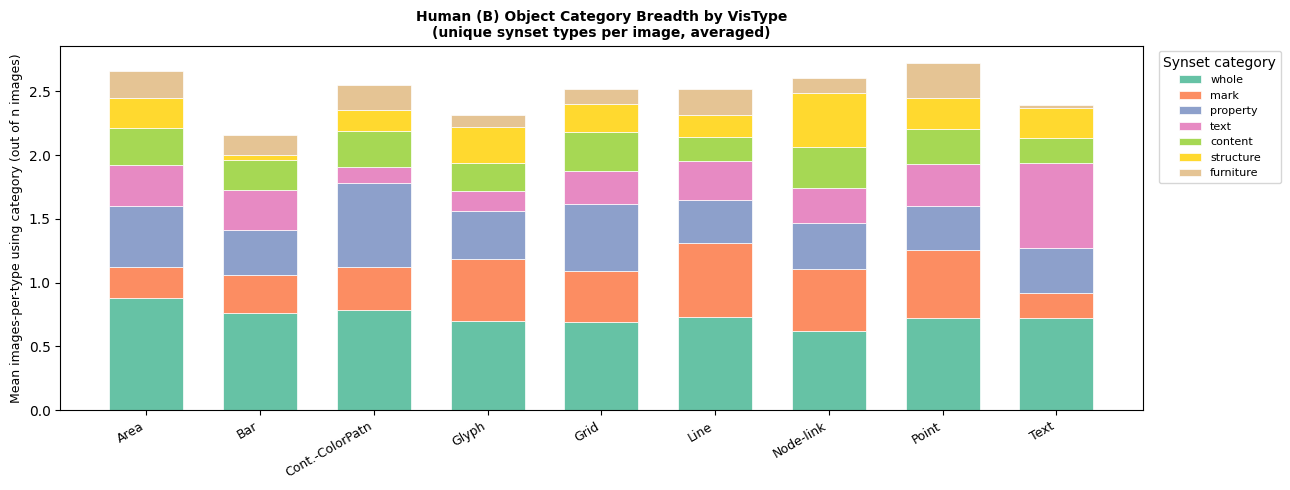

Saved → obj_category_uniq_stacked.png


In [33]:
# ── 1. Deduplication ratio per VisType ────────────────────────────────────
# ratio = uniq / raw  (1.0 = fully diverse, low = heavy repetition)
vol['ratio_obj']  = vol['n_obj_uniq']  / vol['n_obj'].replace(0, np.nan)
vol['ratio_attr'] = vol['n_attr_uniq'] / vol['n_attr'].replace(0, np.nan)
vol['ratio_rel']  = vol['n_rel_uniq']  / vol['n_rel'].replace(0, np.nan)

ratio_pairs = [
    ('ratio_obj',  'Objects',       'n_obj_uniq / n_obj'),
    ('ratio_attr', 'Attributes',    'n_attr_uniq / n_attr'),
    ('ratio_rel',  'Relationships', 'n_rel_uniq / n_rel'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title, ylabel) in zip(axes, ratio_pairs):
    data  = [vol.loc[vol['VisType'] == vt, col].dropna().values for vt in NINE_VIS]
    means = [d.mean() if len(d) else 0 for d in data]
    parts = ax.violinplot(data, positions=range(len(NINE_VIS)),
                          showmedians=True, showextrema=False)
    for body, vt in zip(parts['bodies'], NINE_VIS):
        body.set_facecolor(VT_COLORS[vt])
        body.set_alpha(0.65)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)
    ax.scatter(range(len(NINE_VIS)), means, color='black', s=30, zorder=5, label='mean')
    ax.axhline(1.0, color='grey', lw=0.8, ls='--', alpha=0.6)
    ax.set_ylim(0, 1.1)
    ax.set_xticks(range(len(NINE_VIS)))
    ax.set_xticklabels(NINE_VIS, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Human (B) Deduplication Ratio by VisType\n(1 = fully diverse; lower = more repetition)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUT / 'dedup_ratio_violins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dedup_ratio_violins.png')

# ── 2. Raw vs unique scatter per image (colored by VisType) ───────────────
scatter_pairs = [
    ('n_obj',  'n_obj_uniq',  'Objects'),
    ('n_attr', 'n_attr_uniq', 'Attributes'),
    ('n_rel',  'n_rel_uniq',  'Relationships'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (raw_col, uniq_col, title) in zip(axes, scatter_pairs):
    for vt in NINE_VIS:
        sub = vol[vol['VisType'] == vt]
        ax.scatter(sub[raw_col], sub[uniq_col],
                   color=VT_COLORS[vt], alpha=0.45, s=18, label=vt)
    # diagonal reference (perfect diversity)
    lim = max(vol[raw_col].max(), vol[uniq_col].max()) + 1
    ax.plot([0, lim], [0, lim], color='grey', lw=0.8, ls='--', alpha=0.7, label='y=x')
    ax.set_xlabel(f'Raw {title.lower()} / image', fontsize=9)
    ax.set_ylabel(f'Unique {title.lower()} / image', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlim(left=0); ax.set_ylim(bottom=0)
    if ax == axes[0]:
        ax.legend(fontsize=7, ncol=2, markerscale=1.2)

plt.suptitle('Human (B) Raw vs Unique OAR per Image\n(below diagonal = repetition)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUT / 'raw_vs_unique_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → raw_vs_unique_scatter.png')

# ── 3. Vocabulary breadth: distinct synsets pooled across all images per VT ──
breadth_counts = {}
for vt, imgs in vt_images.items():
    seen = set()
    for img in imgs:
        for obj in b_raw[img]['objects']:
            seen.add(resolve_object_synset(obj['name']))
    breadth_counts[vt] = len(seen)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(NINE_VIS))
bars = ax.bar(x, [breadth_counts[vt] for vt in NINE_VIS],
              color=[VT_COLORS[vt] for vt in NINE_VIS],
              width=0.6, edgecolor='white')
ax.bar_label(bars, fmt='%d', fontsize=8, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(NINE_VIS, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Number of distinct canonical synsets', fontsize=10)
ax.set_title('Human (B) Object Vocabulary Breadth per VisType\n(distinct synsets pooled across all images)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'vocab_breadth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → vocab_breadth.png')

# ── 4. Category profile using unique synsets (1 type per image, then avg) ──
cat_rows_uniq = {}
for vt, imgs in vt_images.items():
    ctr = Counter()
    for img in imgs:
        seen_cats = {synset_category(resolve_object_synset(o['name']))
                     for o in b_raw[img]['objects']}
        for cat in seen_cats:
            ctr[cat] += 1
    n_img = len(imgs)
    cat_rows_uniq[vt] = {k: v / n_img for k, v in ctr.items()} if n_img else {}

cat_df_uniq = pd.DataFrame(cat_rows_uniq, index=all_cats).fillna(0).T.loc[NINE_VIS]
cat_df_uniq = cat_df_uniq[cat_order]  # keep same category order as Section 2

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(NINE_VIS))
x = np.arange(len(NINE_VIS))
for cat, color in zip(cat_order, CAT_COLORS):
    vals = cat_df_uniq[cat].values
    ax.bar(x, vals, bottom=bottom, label=cat, color=color,
           width=0.65, edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(NINE_VIS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean images-per-type using category (out of n images)', fontsize=9)
ax.legend(title='Synset category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_title('Human (B) Object Category Breadth by VisType\n(unique synset types per image, averaged)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'obj_category_uniq_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → obj_category_uniq_stacked.png')


## 2. Object Category Profile

In [29]:
# ── Synset category: prefix before '.' ────────────────────────────────────
def synset_category(synset: str) -> str:
    return synset.split('.')[0] if '.' in synset else 'unknown'

# Build per-VisType category counts (normalised to fraction of total tokens)
cat_rows = {}
for vt, imgs in vt_images.items():
    ctr = Counter()
    for img in imgs:
        for obj in b_raw[img]['objects']:
            syn = resolve_object_synset(obj['name'])
            ctr[synset_category(syn)] += 1
    total = sum(ctr.values())
    cat_rows[vt] = {k: v / total for k, v in ctr.items()} if total else {}

# All categories present
all_cats = sorted({cat for row in cat_rows.values() for cat in row})
cat_df = pd.DataFrame(cat_rows, index=all_cats).fillna(0).T.loc[NINE_VIS]

# Sort categories by overall frequency for cleaner legend
cat_order = cat_df.sum().sort_values(ascending=False).index.tolist()
cat_df = cat_df[cat_order]

print('Object token category fractions per VisType:')
display(cat_df.round(3))
cat_df.to_csv(OUT / 'obj_category_profile.csv')

Object token category fractions per VisType:


,whole,mark,property,text,content,structure,furniture
Area,0.303,0.090,0.181,0.122,0.106,0.096,0.101
Bar,0.328,0.131,0.164,0.172,0.123,0.016,0.066
Cont.-ColorPatn,0.295,0.180,0.238,0.049,0.115,0.057,0.066
Glyph,0.288,0.252,0.153,0.061,0.092,0.117,0.037
Grid,0.258,0.159,0.192,0.115,0.126,0.093,0.055
Line,0.259,0.259,0.112,0.140,0.070,0.063,0.098
Node-link,0.213,0.223,0.119,0.099,0.119,0.188,0.040
Point,0.229,0.240,0.109,0.125,0.099,0.083,0.115
Text,0.290,0.087,0.152,0.283,0.080,0.101,0.007


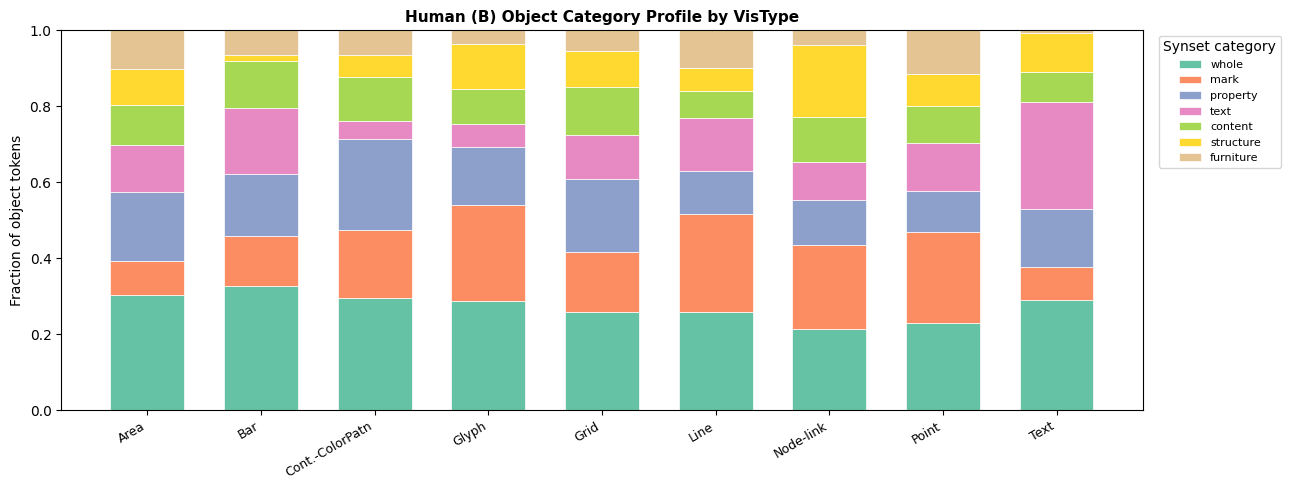

Saved → obj_category_stacked.png


In [30]:
# ── Stacked bar: category fraction per VisType ─────────────────────────────
CAT_COLORS = plt.cm.Set2.colors[:len(cat_order)]

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(NINE_VIS))
x      = np.arange(len(NINE_VIS))

for cat, color in zip(cat_order, CAT_COLORS):
    vals = cat_df[cat].values
    ax.bar(x, vals, bottom=bottom, label=cat, color=color, width=0.65, edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(NINE_VIS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Fraction of object tokens', fontsize=10)
ax.set_ylim(0, 1)
ax.legend(title='Synset category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_title('Human (B) Object Category Profile by VisType', fontsize=11, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'obj_category_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → obj_category_stacked.png')

## 3. Cross-VisType Vocabulary Similarity

In [31]:
# ── Build per-VisType synset frequency vectors ─────────────────────────────
vt_synset_ctr = {}
for vt, imgs in vt_images.items():
    ctr = Counter()
    for img in imgs:
        for obj in b_raw[img]['objects']:
            ctr[resolve_object_synset(obj['name'])] += 1
    vt_synset_ctr[vt] = ctr

all_synsets = sorted({s for ctr in vt_synset_ctr.values() for s in ctr})
print(f'Total distinct synsets across all VisTypes: {len(all_synsets)}')

# ── Pairwise Jaccard on synset TYPE sets (presence/absence) ────────────────
vt_sets = {vt: set(ctr.keys()) for vt, ctr in vt_synset_ctr.items()}

n = len(NINE_VIS)
jaccard_mat = np.zeros((n, n))
for i, vt_a in enumerate(NINE_VIS):
    for j, vt_b in enumerate(NINE_VIS):
        inter = len(vt_sets[vt_a] & vt_sets[vt_b])
        union = len(vt_sets[vt_a] | vt_sets[vt_b])
        jaccard_mat[i, j] = inter / union if union else 0

jaccard_df = pd.DataFrame(jaccard_mat, index=NINE_VIS, columns=NINE_VIS)

# ── Pairwise cosine similarity on frequency vectors ────────────────────────
tf_mat = np.array([[vt_synset_ctr[vt].get(s, 0) for s in all_synsets]
                   for vt in NINE_VIS], dtype=float)
# L2-normalise each row
norms = np.linalg.norm(tf_mat, axis=1, keepdims=True)
tf_norm = tf_mat / np.where(norms == 0, 1, norms)
cosine_mat = tf_norm @ tf_norm.T
cosine_df = pd.DataFrame(cosine_mat, index=NINE_VIS, columns=NINE_VIS)

print('\nJaccard (type set) diagonal:', np.diag(jaccard_mat).round(3))
print('Cosine diagonal:', np.diag(cosine_mat).round(3))

jaccard_df.to_csv(OUT / 'vistype_jaccard.csv')
cosine_df.to_csv(OUT / 'vistype_cosine.csv')

Total distinct synsets across all VisTypes: 37

Jaccard (type set) diagonal: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Cosine diagonal: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


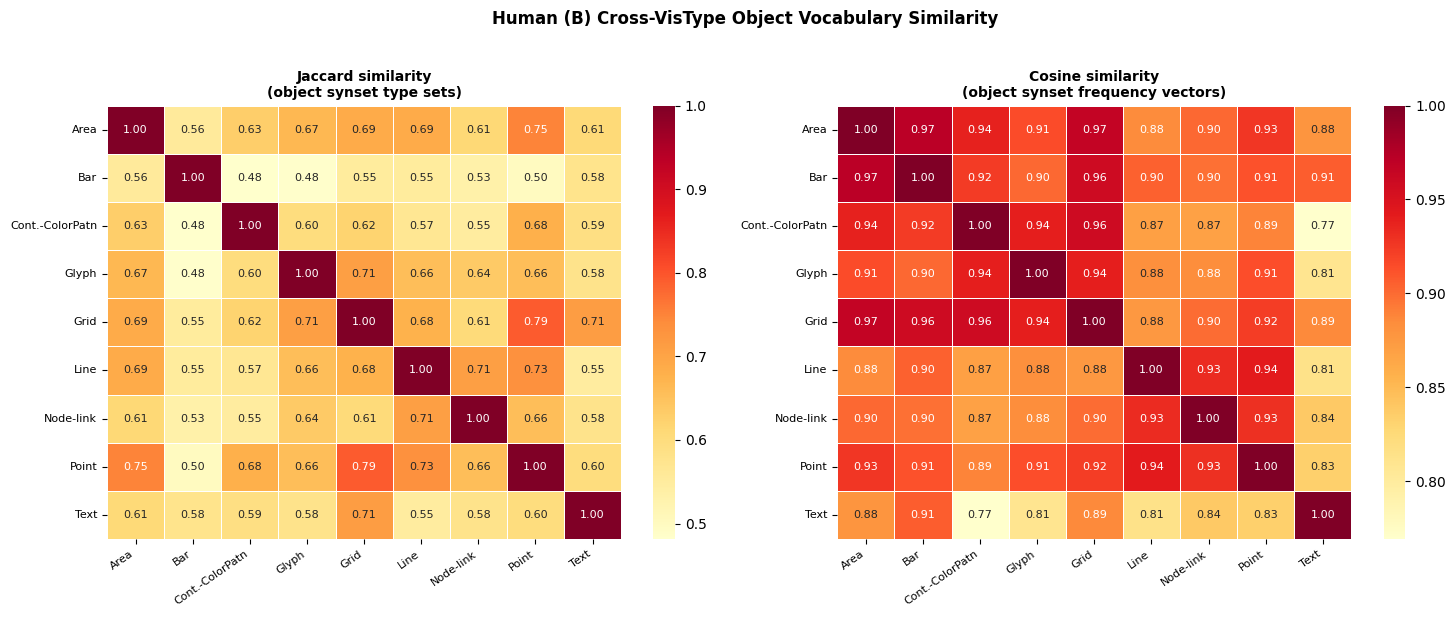

Saved → vistype_similarity_heatmap.png


In [32]:
# ── Plot both heatmaps side-by-side ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

def sim_heatmap(ax, df, title, vmin=0, vmax=1):
    mask = np.eye(len(df), dtype=bool)  # mask diagonal so it doesn't dominate scale
    sns.heatmap(df, ax=ax, annot=True, fmt='.2f', cmap='YlOrRd',
                vmin=vmin, vmax=vmax,
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 8})
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

sim_heatmap(ax1, jaccard_df,
            'Jaccard similarity\n(object synset type sets)',
            vmin=jaccard_df.values[~np.eye(n, dtype=bool)].min(),
            vmax=1.0)
sim_heatmap(ax2, cosine_df,
            'Cosine similarity\n(object synset frequency vectors)',
            vmin=cosine_df.values[~np.eye(n, dtype=bool)].min(),
            vmax=1.0)

plt.suptitle('Human (B) Cross-VisType Object Vocabulary Similarity',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUT / 'vistype_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → vistype_similarity_heatmap.png')

## 4. VisType-Specific vs Shared Vocabulary

In [22]:
# ── For each synset, count how many VisTypes use it ────────────────────────
synset_vt_count = Counter({s: sum(1 for ctr in vt_synset_ctr.values() if s in ctr)
                            for s in all_synsets})

universal = [s for s, c in synset_vt_count.items() if c == 9]
exclusive = {vt: [] for vt in NINE_VIS}
for s in all_synsets:
    if synset_vt_count[s] == 1:
        for vt in NINE_VIS:
            if s in vt_sets[vt]:
                exclusive[vt].append((s, vt_synset_ctr[vt][s]))

print(f'Synsets used in ALL 9 VisTypes ({len(universal)}): {sorted(universal)}')
print()
for vt in NINE_VIS:
    excl = sorted(exclusive[vt], key=lambda x: -x[1])
    top  = excl[:8]
    print(f'{vt:20s}  {len(exclusive[vt]):2d} exclusive  '
          f'top: {[f"{s}({c})" for s,c in top]}')

Synsets used in ALL 9 VisTypes (9): ['content.data', 'content.number', 'mark.line', 'mark.point', 'mark.shape', 'property.color', 'structure.layout', 'text.label', 'whole.visualization']

Area                   0 exclusive  top: []
Bar                    0 exclusive  top: []
Cont.-ColorPatn        0 exclusive  top: []
Glyph                  2 exclusive  top: ['property.size(1)', 'property.texture(1)']
Grid                   1 exclusive  top: ['property.opacity(1)']
Line                   0 exclusive  top: []
Node-link              1 exclusive  top: ['mark.node(2)']
Point                  0 exclusive  top: []
Text                   0 exclusive  top: []


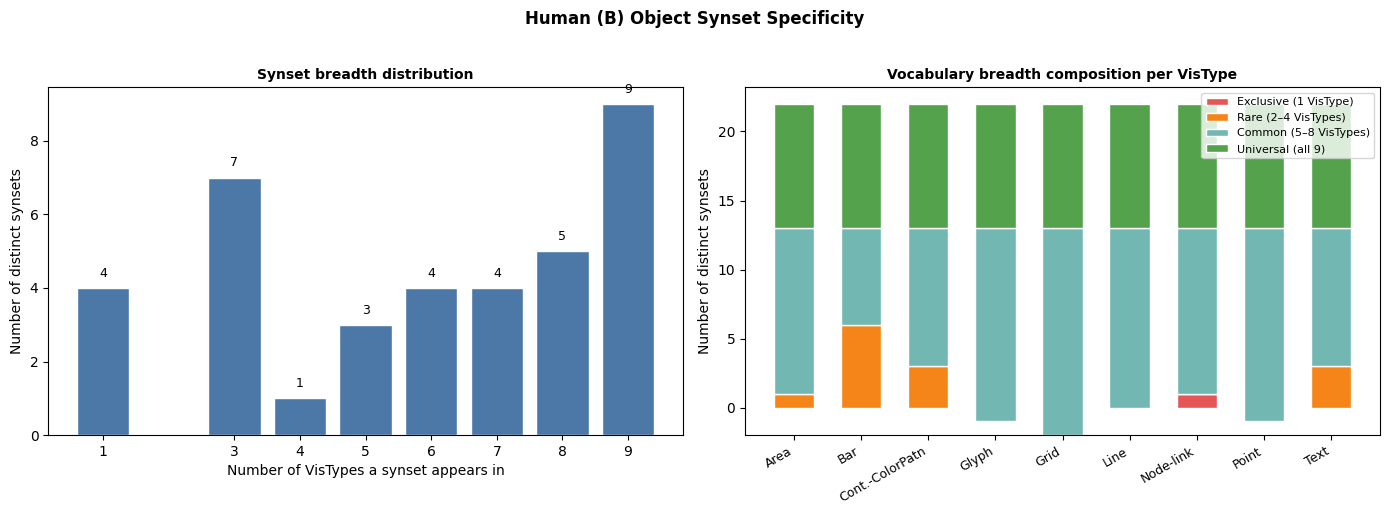

Saved → synset_specificity.png


In [23]:
# ── Plot: synset breadth distribution (histogram of how many VisTypes each synset spans)
# and stacked bar showing exclusive / shared vocab size per VisType
breadth_counts = Counter(synset_vt_count.values())  # {n_vistypes: n_synsets}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: breadth histogram
xs = sorted(breadth_counts)
ax1.bar(xs, [breadth_counts[x] for x in xs], color='#4C78A8', edgecolor='white')
ax1.set_xlabel('Number of VisTypes a synset appears in', fontsize=10)
ax1.set_ylabel('Number of distinct synsets', fontsize=10)
ax1.set_title('Synset breadth distribution', fontsize=10, fontweight='bold')
ax1.set_xticks(xs)
for x in xs:
    ax1.text(x, breadth_counts[x] + 0.3, str(breadth_counts[x]),
             ha='center', fontsize=9)

# Right: per-VisType vocabulary composition
n_exclusive   = [len(exclusive[vt]) for vt in NINE_VIS]
n_majority    = [sum(1 for s in vt_sets[vt] if 5 <= synset_vt_count[s] <= 8) for vt in NINE_VIS]
n_universal_v = [sum(1 for s in vt_sets[vt] if synset_vt_count[s] == 9) for vt in NINE_VIS]
n_minority    = [len(vt_sets[vt]) - n_exclusive[i] - n_majority[i] - n_universal_v[i]
                 for i, _ in enumerate(NINE_VIS)]

x = np.arange(len(NINE_VIS))
ax2.bar(x, n_exclusive,   label='Exclusive (1 VisType)',  color='#e45756', width=0.6, edgecolor='white')
ax2.bar(x, n_minority,    bottom=n_exclusive,             label='Rare (2–4 VisTypes)',    color='#f58518', width=0.6, edgecolor='white')
ax2.bar(x, n_majority,    bottom=np.array(n_exclusive)+np.array(n_minority),
        label='Common (5–8 VisTypes)',   color='#72b7b2', width=0.6, edgecolor='white')
ax2.bar(x, n_universal_v, bottom=np.array(n_exclusive)+np.array(n_minority)+np.array(n_majority),
        label='Universal (all 9)',       color='#54a24b', width=0.6, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(NINE_VIS, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Number of distinct synsets', fontsize=10)
ax2.set_title('Vocabulary breadth composition per VisType', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8)

plt.suptitle('Human (B) Object Synset Specificity', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUT / 'synset_specificity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → synset_specificity.png')

## 5. Predicate Profile per VisType

In [24]:
# ── Per-VisType predicate frequency vectors ────────────────────────────────
vt_pred_ctr = {}
for vt, imgs in vt_images.items():
    ctr = Counter()
    for img in imgs:
        for rel in b_raw[img]['relationships']:
            ctr[resolve_predicate(rel['pred'])] += 1
    vt_pred_ctr[vt] = ctr

all_preds = sorted({p for ctr in vt_pred_ctr.values() for p in ctr})
print(f'Total distinct predicates: {len(all_preds)}')

# Pairwise cosine on predicate vectors
pred_mat = np.array([[vt_pred_ctr[vt].get(p, 0) for p in all_preds]
                     for vt in NINE_VIS], dtype=float)
pred_norms = np.linalg.norm(pred_mat, axis=1, keepdims=True)
pred_norm  = pred_mat / np.where(pred_norms == 0, 1, pred_norms)
pred_cosine_mat = pred_norm @ pred_norm.T
pred_cosine_df  = pd.DataFrame(pred_cosine_mat, index=NINE_VIS, columns=NINE_VIS)
pred_cosine_df.to_csv(OUT / 'vistype_pred_cosine.csv')

Total distinct predicates: 422


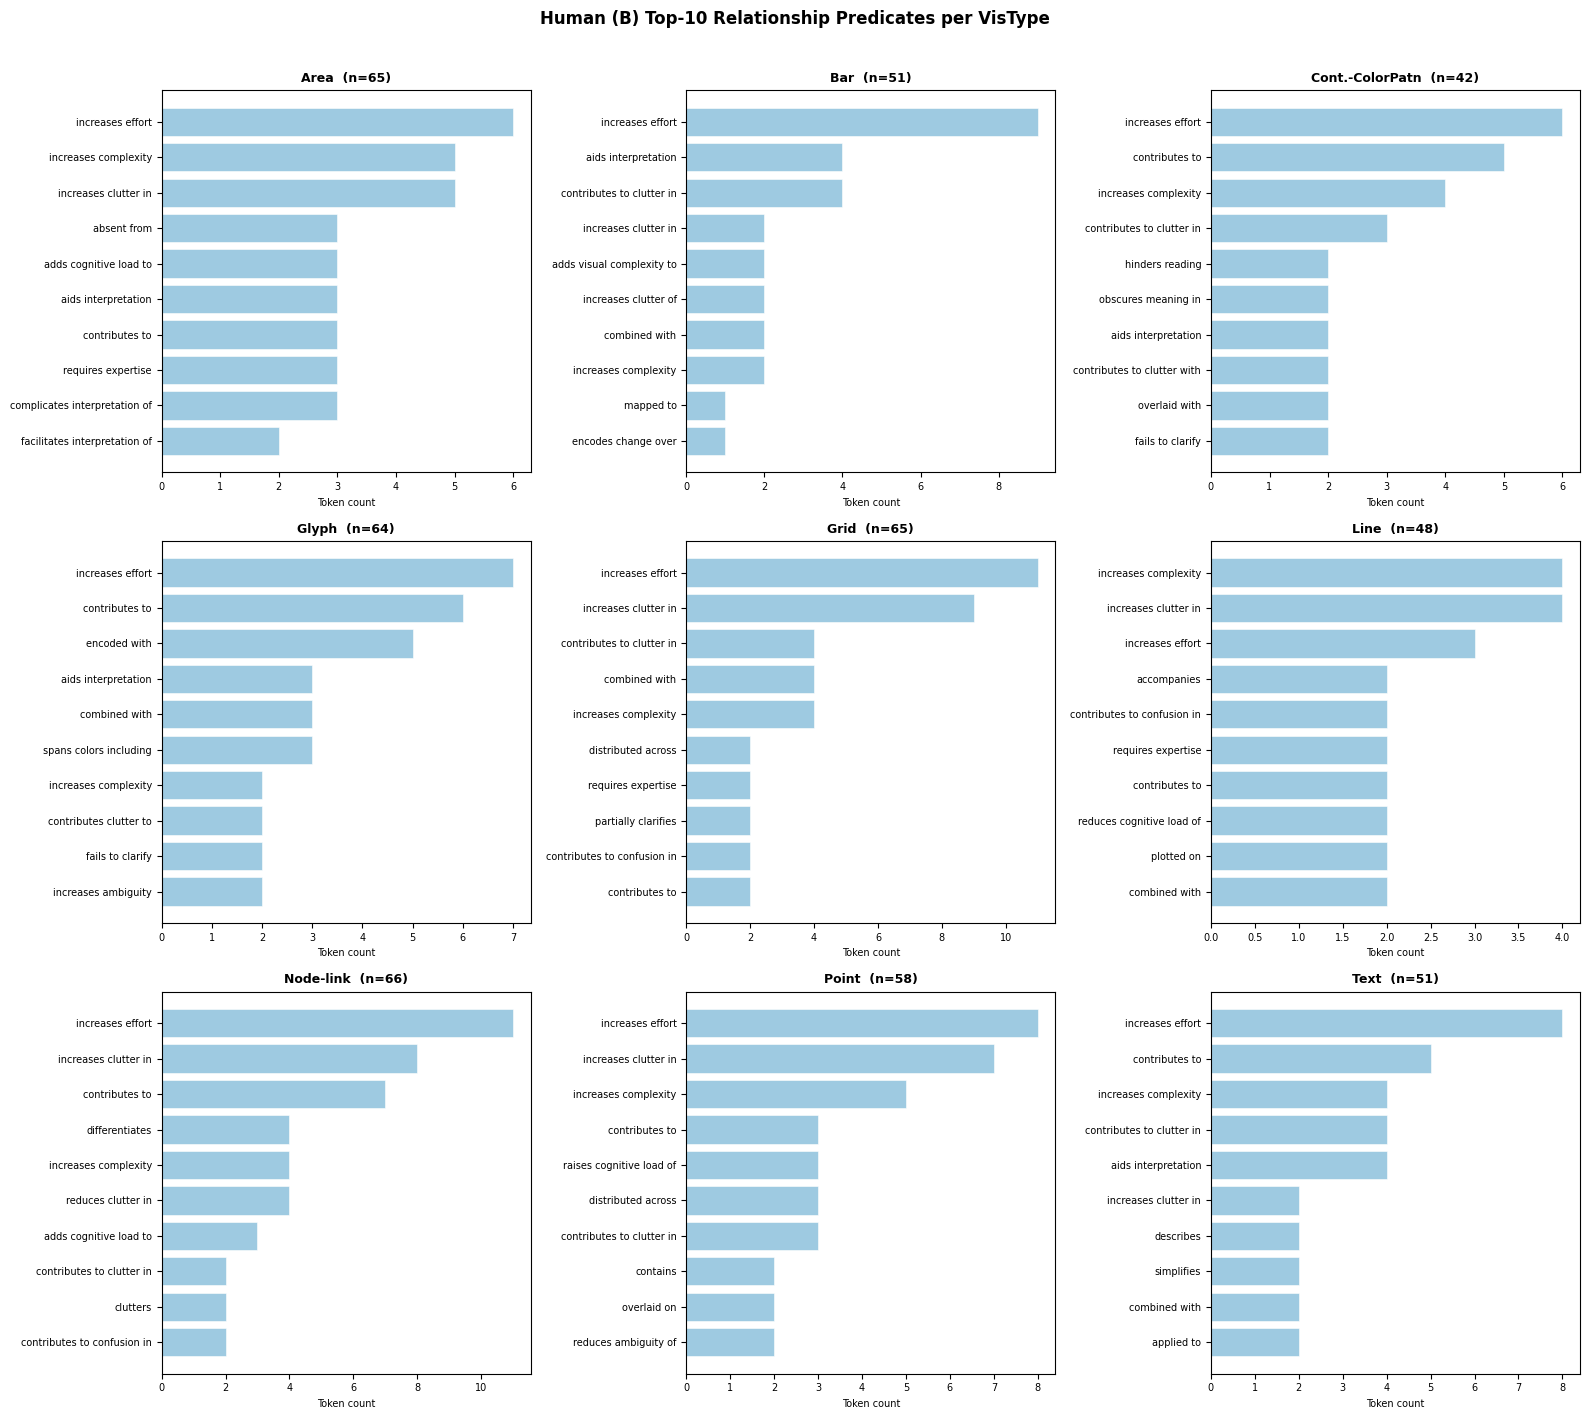

Saved → pred_top10_grid.png


In [25]:
# ── Top-10 predicates per VisType (horizontal bar 3×3 grid) ───────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
TOP_N = 10
PRED_COLOR = '#9ecae1'

for ax, vt in zip(axes.flatten(), NINE_VIS):
    ctr  = vt_pred_ctr[vt]
    top  = ctr.most_common(TOP_N)
    if not top:
        ax.axis('off'); continue
    terms, counts = zip(*reversed(top))
    y = np.arange(len(terms))
    ax.barh(y, counts, color=PRED_COLOR, edgecolor='white', linewidth=0.4)
    ax.set_yticks(y)
    ax.set_yticklabels([t.replace('_', ' ') for t in terms], fontsize=7)
    ax.set_title(f'{vt}  (n={len(vt_images[vt])})', fontsize=9, fontweight='bold')
    ax.set_xlabel('Token count', fontsize=7)
    ax.tick_params(axis='x', labelsize=7)

plt.suptitle('Human (B) Top-10 Relationship Predicates per VisType',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(OUT / 'pred_top10_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → pred_top10_grid.png')

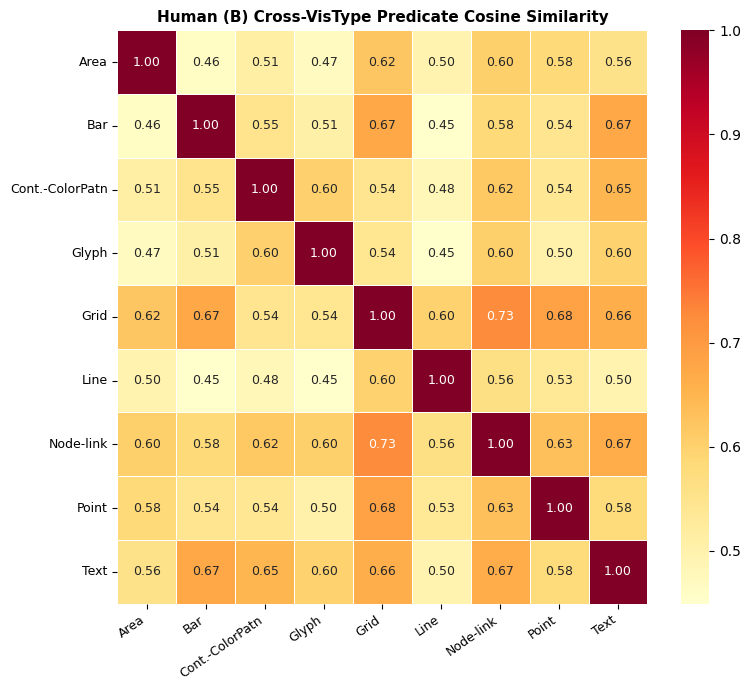

Saved → pred_cosine_heatmap.png


In [26]:
# ── Predicate cosine similarity heatmap ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
off_diag_min = pred_cosine_df.values[~np.eye(len(NINE_VIS), dtype=bool)].min()
sns.heatmap(pred_cosine_df, ax=ax, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=off_diag_min, vmax=1.0,
            linewidths=0.5, linecolor='white', annot_kws={'size': 9})
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title('Human (B) Cross-VisType Predicate Cosine Similarity',
             fontsize=11, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'pred_cosine_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → pred_cosine_heatmap.png')

## 6. Summary

In [36]:
# ── Consolidated summary table ─────────────────────────────────────────────
universal_set = set(universal)

rows_sum = []
for vt in NINE_VIS:
    sub   = vol[vol['VisType'] == vt]
    n_img = len(sub)
    # Mean number of universal-synset object tokens per image in this VisType
    univ_tokens_per_img = (
        sum(
            sum(1 for o in b_raw[img]['objects']
                if resolve_object_synset(o['name']) in universal_set)
            for img in vt_images[vt]
        ) / n_img if n_img else 0
    )
    rows_sum.append({
        'VisType':                  vt,
        'n_images':                 n_img,
        # Raw counts
        'obj/img':                  sub['n_obj'].mean().round(2),
        'attr/img':                 sub['n_attr'].mean().round(2),
        'rel/img':                  sub['n_rel'].mean().round(2),
        # Unique (deduplicated) counts
        'obj_uniq/img':             sub['n_obj_uniq'].mean().round(2),
        'attr_uniq/img':            sub['n_attr_uniq'].mean().round(2),
        'rel_uniq/img':             sub['n_rel_uniq'].mean().round(2),
        # Deduplication ratios
        'dedup_obj':                sub['ratio_obj'].mean().round(3),
        'dedup_attr':               sub['ratio_attr'].mean().round(3),
        'dedup_rel':                sub['ratio_rel'].mean().round(3),
        # Vocabulary
        'n_synsets':                len(vt_sets[vt]),
        'n_exclusive':              len(exclusive[vt]),
        'univ_tokens/img':          round(univ_tokens_per_img, 2),
        'n_preds':                  len(vt_pred_ctr[vt]),
    })

sum_df = pd.DataFrame(rows_sum).set_index('VisType')
display(sum_df)
sum_df.to_csv(OUT / 'vistype_oar_summary.csv')
print('Saved → vistype_oar_summary.csv')

,n_images,obj/img,attr/img,rel/img,obj_uniq/img,attr_uniq/img,rel_uniq/img,dedup_obj,dedup_attr,dedup_rel,n_synsets,n_exclusive,univ_tokens/img,n_preds
VisType,,,,,,,,,,,,,,
Area,65,2.89,4.31,1.85,2.82,4.31,1.85,0.987,1.000,1.000,23,0,2.18,88
Bar,51,2.39,2.84,1.29,2.27,2.84,1.29,0.963,1.000,1.000,19,0,1.90,47
Cont.-ColorPatn,42,2.90,3.93,1.93,2.76,3.93,1.93,0.954,1.000,1.000,21,0,2.31,60
Glyph,64,2.55,3.20,1.56,2.48,3.20,1.53,0.981,1.000,0.991,27,2,1.91,72
Grid,65,2.80,3.63,1.72,2.68,3.63,1.72,0.973,1.000,1.000,26,1,2.18,78
Line,48,2.98,3.48,1.81,2.83,3.44,1.81,0.956,0.989,1.000,26,0,2.25,69
Node-link,66,3.06,4.11,2.05,2.92,4.11,2.05,0.968,1.000,1.000,27,1,2.33,91
Point,58,3.31,4.29,2.19,3.10,4.28,2.17,0.955,0.996,0.995,26,0,2.50,93
Text,51,2.71,3.24,1.73,2.55,3.24,1.73,0.956,1.000,1.000,22,0,2.31,63


Saved → vistype_oar_summary.csv
